<a href="https://colab.research.google.com/github/tatyanalitvin/python_for_ds_tasks/blob/dev/Unit_02/HW_2_3/HW_2_4_kNN_%D0%9A%D1%80%D0%BE%D1%81%D0%B2%D0%B0%D0%BB%D1%96%D0%B4%D0%B0%D1%86%D1%96%D1%8F_%D1%96_%D1%82%D1%8E%D0%BD%D0%B8%D0%BD%D0%B3_%D0%B3%D1%96%D0%BF%D0%B5%D1%80%D0%BF%D0%B0%D1%80%D0%B0%D0%BC%D0%B5%D1%82%D1%80%D1%96%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
!pip install mlxtend

In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)

import numpy as np
import time

# Training
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import f1_score

# Charts
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.facecolor'] = '#00000000'

import seaborn as sns
sns.set_style('darkgrid')

from mlxtend.plotting import plot_decision_regions


# Kaggle Setup

In [36]:
import os
from google.colab import userdata
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

In [37]:
# in case of error, rerun the cell, sometimes creds from the previoues cell take more time to load
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.set_config_value("username", userdata.get("KAGGLE_USERNAME"), quiet=True)
api.set_config_value("key", userdata.get("KAGGLE_API_TOKEN"), quiet=True)

In [38]:
def load_competition_data(competition):
    files = api.competition_list_files(competition).files
    for file in files:
        print(file.name)

    return {
        f.name[:-4]: (
            api.competition_download_file(competition, f.name, path='.'),
            pd.read_csv(f.name)
        )[1]
        for f in files if f.name.endswith('.csv')
    }

In [39]:
competition = "bank-customer-churn-prediction-dlu-course-c-4"

dfs = load_competition_data(competition)

raw_train_df = dfs["train"].set_index("id")
raw_test_df = dfs["test"].set_index("id")
raw_sample_submission = dfs["sample_submission"]

sample_submission.csv
test.csv
train.csv
sample_submission.csv: Skipping, found more recently modified local copy (use --force to force download)
test.csv: Skipping, found more recently modified local copy (use --force to force download)
train.csv: Skipping, found more recently modified local copy (use --force to force download)


# Tasks

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

## Завдання 0.
Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [40]:
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/ML for People/HW_2_3')

from process_bank_churn import preprocess_data, preprocess_new_data

In [41]:
EXCLUDE_COLS = ["CustomerId", "Surname", "Exited"]
TARGET_COL = "Exited"

X_train, train_targets, X_val, val_targets, input_cols, scaler, encoder = preprocess_data(
    raw_df = raw_train_df,
    exclude_cols = EXCLUDE_COLS,
    target_col = TARGET_COL,
    )

In [42]:
# # Додала SMOTE, бо не подобалося, що модель значно гірші результати за поліноміальну давала,
# # так різниця хоч трохи менша
# smote = SMOTE(
#     random_state = 42,
#     k_neighbors = 5, # не впевнена як визначати скільки сусідів брати для такого датасету, взяла 5 але не знаю чи то багато чи ок
#     sampling_strategy = "auto",
#     )

# X_train, train_targets = smote.fit_resample(X_train, train_targets)


## Завдання 1.
Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [43]:
knn = KNeighborsClassifier()
knn.fit(X_train, train_targets)

KNeighborsClassifier()

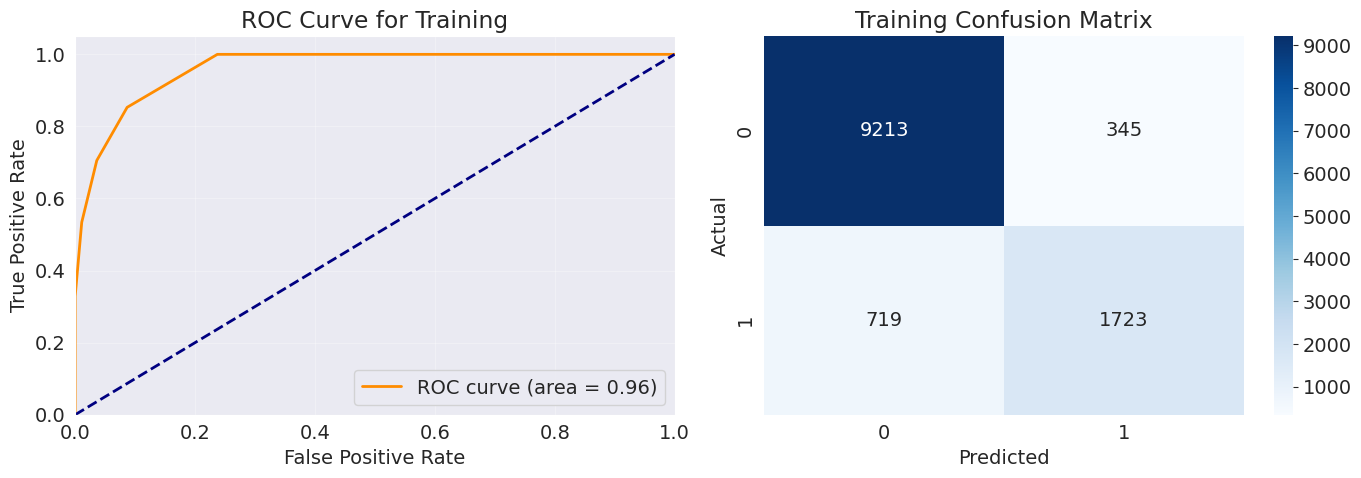

===== Training Results =====
    AUROC: 0.9620
    F1 Score: 0.7641
    




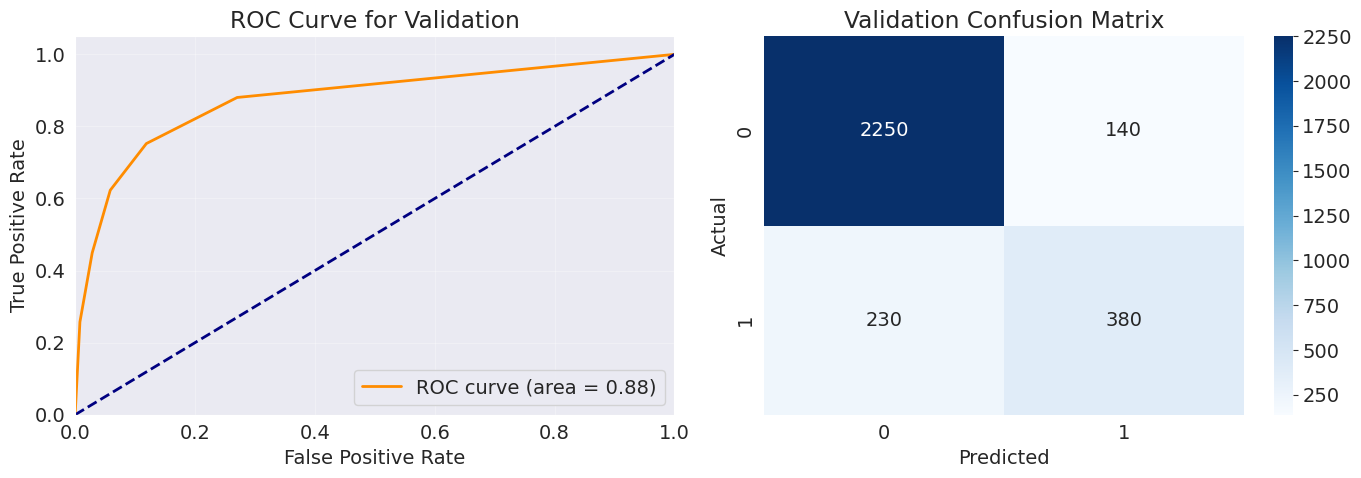

===== Validation Results =====
    AUROC: 0.8755
    F1 Score: 0.6726
    




In [44]:
def predict_and_plot(model, inputs, targets, name=""):
    y_pred = model.predict(inputs)
    y_pred_proba = model.predict_proba(inputs)[:, 1]

    # ROC curve
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

    # metrics
    roc_auc = auc(fpr, tpr)
    f1 = f1_score(targets, y_pred)
    cm = confusion_matrix(targets, y_pred)

    # 2 графіки поруч для зручності
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ROC curve зліва
    axes[0].plot(
        fpr, tpr,
        color="darkorange",
        lw=2,
        label=f"ROC curve (area = {roc_auc:.2f})"
        )
    axes[0].plot(
        [0, 1], [0, 1],
        color="navy",
        lw=2,
        linestyle="--"
        )
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"ROC Curve for {name}")
    axes[0].legend(loc="lower right")
    axes[0].grid(True, alpha=0.3)

    # confusion matrix зправа
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[1],
        cbar=True
        )
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")
    axes[1].set_title(f"{name} Confusion Matrix")

    plt.tight_layout()
    plt.show()

    # Print results
    print(f"""===== {name} Results =====
    AUROC: {roc_auc:.4f}
    F1 Score: {f1:.4f}
    \n\n""")

    return y_pred, roc_auc

train_preds, _ = predict_and_plot(knn, X_train, train_targets, "Training")
val_preds, _ = predict_and_plot(knn, X_val, val_targets, "Validation")

**Висновок:**

Модель kNN з параметрами за замовченням (k=5) показала наступні результати:

Різниця між тренувальним AUROC (0.9620) та валідаційним AUROC (0.8755) є відчутною, що свідчить про високу дисперсію (high variance / overfitting). Модель генералізує гірше на нових даних.

Валідаційний AUROC 0.8755 виглядає непогано, але в минулих роботах були результати і краще :)

## Завдання 2.
Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [45]:
knn = KNeighborsClassifier()

params_knn = {'n_neighbors': np.arange(1, 25)}

knn_gs = GridSearchCV(
    knn,
    params_knn,
    cv=5,
    scoring='roc_auc'
    )

knn_gs.fit(X_train, train_targets)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])},
             scoring='roc_auc')

In [46]:
knn_best = knn_gs.best_estimator_

print(knn_gs.best_params_, knn_gs.best_score_)

{'n_neighbors': np.int64(23)} 0.9130310734490831


In [47]:
knn_best = knn_gs.best_estimator_
knn_best

KNeighborsClassifier(n_neighbors=np.int64(23))

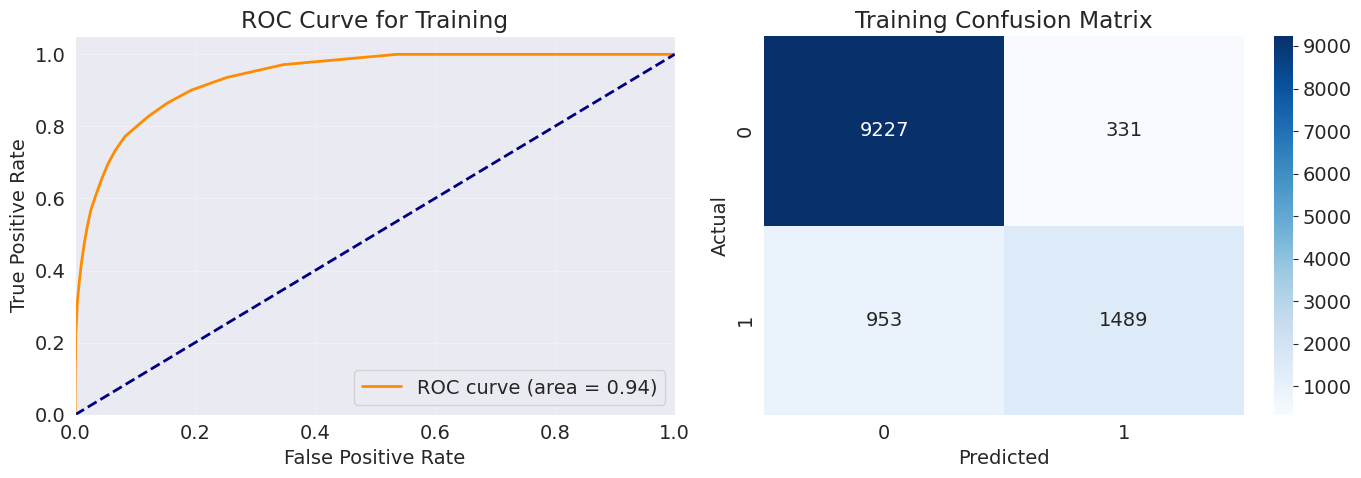

===== Training Results =====
    AUROC: 0.9379
    F1 Score: 0.6987
    




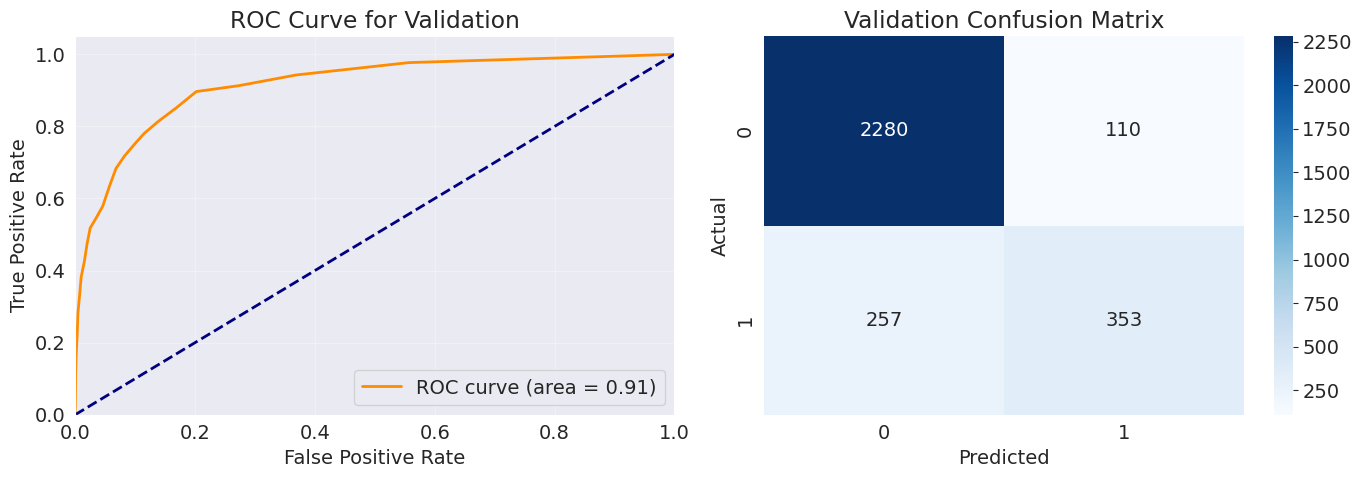

===== Validation Results =====
    AUROC: 0.9139
    F1 Score: 0.6580
    




In [48]:
train_preds, _ = predict_and_plot(knn_best, X_train, train_targets, "Training")
val_preds, _ = predict_and_plot(knn_best, X_val, val_targets, "Validation")

**Висновок:**
Чи стала модель краще? Так. Хоча тренувальний AUROC знизився (з 0.9620 до 0.9379), валідаційний AUROC суттєво зріс (з 0.8755 до 0.9139). Це свідчить про те, що модель з k=23 менше перенавчається (overfitting) і краще генералізує на нових даних.

## Завдання 3.
Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [49]:
dt = DecisionTreeClassifier(random_state=42)

params_grid_dt = {
    'max_depth': np.arange(1, 21, 2),       # 1,3..20
    'max_leaf_nodes': np.arange(2, 11, 1)    # 2,3.. 10
}

dt_gs = GridSearchCV(
    dt,
    params_grid_dt,
    cv=3,
    scoring='roc_auc'
    )

start = time.time()
dt_gs.fit(X_train, train_targets)
elapsed = time.time() - start

print(f"Search time: {elapsed:.2f}s")

Search time: 6.77s


In [50]:
print("Best params:", dt_gs.best_params_)
print(f"Best CV AUROC: {dt_gs.best_score_:.4f}")

dt_best = dt_gs.best_estimator_

Best params: {'max_depth': np.int64(5), 'max_leaf_nodes': np.int64(10)}
Best CV AUROC: 0.9014


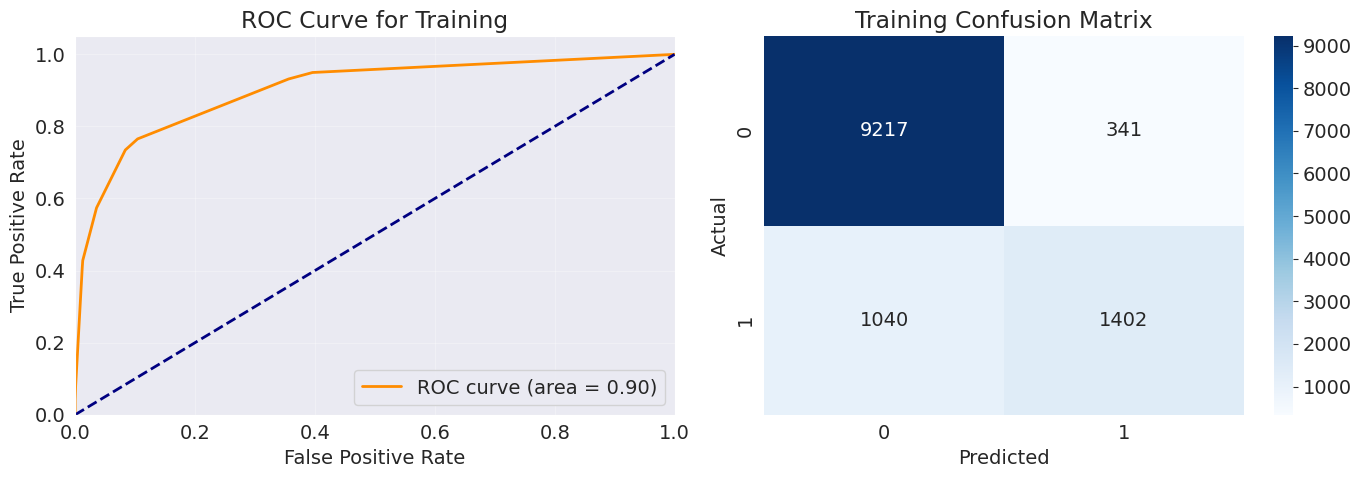

===== Training Results =====
    AUROC: 0.9015
    F1 Score: 0.6700
    




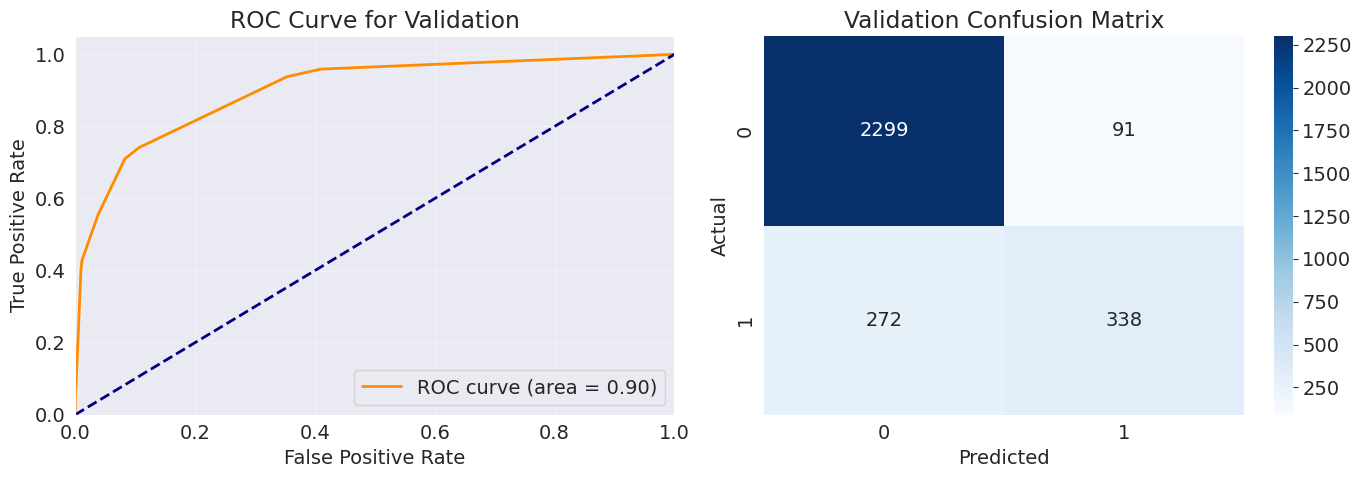

===== Validation Results =====
    AUROC: 0.9002
    F1 Score: 0.6506
    




In [51]:
train_preds, train_auroc = predict_and_plot(dt_best, X_train, train_targets, "Training")
val_preds, val_auroc     = predict_and_plot(dt_best, X_val,   val_targets,   "Validation")

**Висновок:**

Чи ця модель краща за ту, що знайдена вручну? Дерево з підібраними гіперпараметрами через GridSearchCV демонструє дуже стабільні результати — різниця між Train AUROC (0.9015) і Validation AUROC (0.9002) мінімальна, що свідчить про грану генералізацію моделі.

## Завдання 4.
Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [52]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [53]:
dt_rs = RandomizedSearchCV(
    dt,
    params_dt,
    n_iter=40,
    cv=3,
    scoring='roc_auc',
    random_state=42
)

In [54]:
start = time.time()
dt_rs.fit(X_train, train_targets)
elapsed = time.time() - start

print(f"RandomizedSearch time: {elapsed:.2f}s")

RandomizedSearch time: 2.69s


In [55]:
print("Best params:", dt_rs.best_params_)
print(f"Best CV AUROC: {dt_rs.best_score_:.4f}")

dt_random_search_best = dt_rs.best_estimator_

Best params: {'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'}
Best CV AUROC: 0.9109


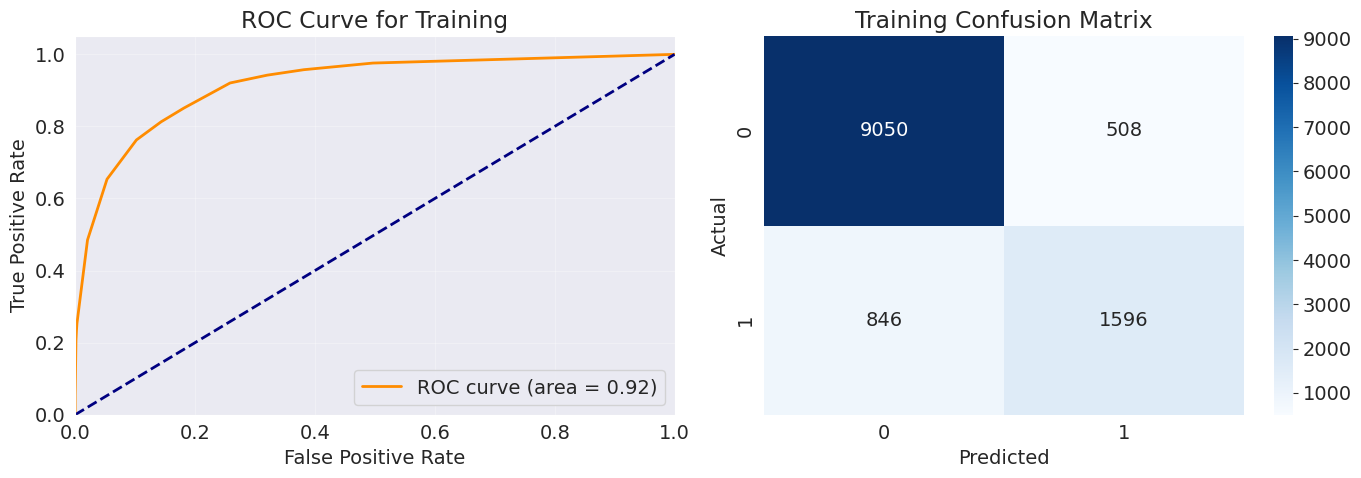

===== Training Results =====
    AUROC: 0.9169
    F1 Score: 0.7022
    




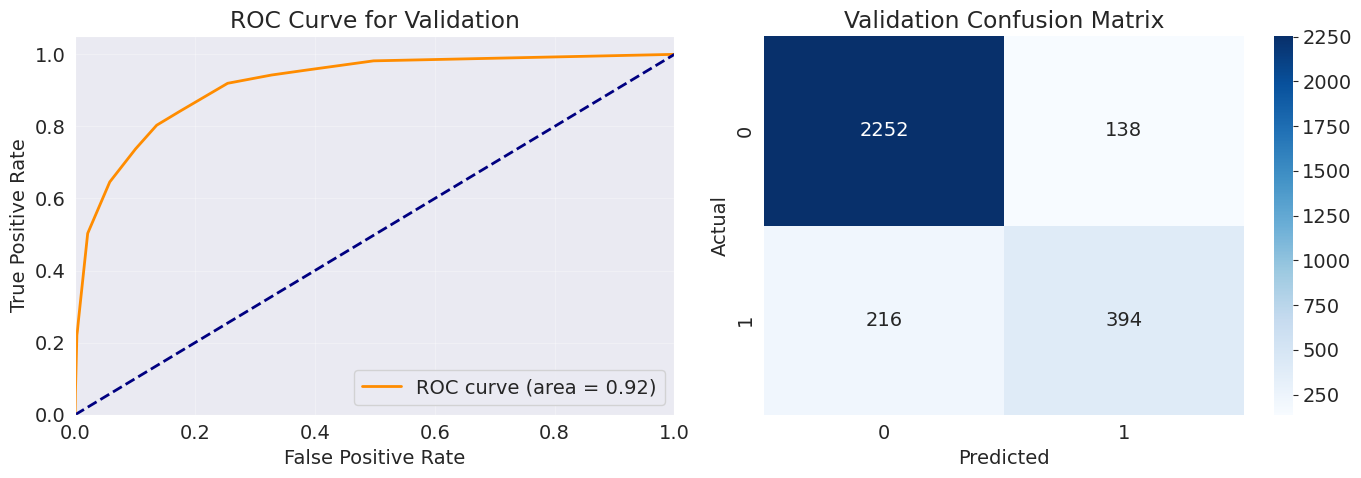

===== Validation Results =====
    AUROC: 0.9166
    F1 Score: 0.6900
    




In [56]:
train_preds, train_auroc = predict_and_plot(dt_random_search_best, X_train, train_targets, "Training")
val_preds, val_auroc     = predict_and_plot(dt_random_search_best, X_val,   val_targets,   "Validation")

**Висновок:**

Чи ця модель краща? Так, модель знайдена RandomizedSearchCV значно краща за модель з GridSearchCV:

Validation AUROC зріс з 0.9002 до 0.9166, a Validation F1 зріс з 0.6506 до 0.6900. І навіть час пошуку значно впав.
Аналіз відмінностей параметрів:

RandomizedSearchCV знайшов глибше дерево (depth=16 vs 5) з більшою кількістю листків (14 vs 10) та criterion=entropy замість gini. При цьому regularization параметри (min_samples_split=20, min_samples_leaf=2) допомагають avoid overfitting (мінімальна різниця між Train і Validation AUROC)

Виходить, що RandomizedSearchCV з ширшою сіткою параметрів може бути ефективнішим за GridSearchCV з вузькою сіткою, адже вдалося дослідити більший простір гіперпараметрів за менший час

## Завдання 5.
Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [57]:
best_model = dt_best

In [58]:
X_test = preprocess_new_data(
    new_df=raw_test_df,
    input_cols=input_cols,
    scaler=scaler,
    encoder=encoder
    )
test_preds = best_model.predict_proba(X_test)[:, 1]

submission = raw_sample_submission.copy()
submission["Exited"] = test_preds

submission.to_csv("submission_decision_tree.csv", index=False)
submission.head()

,id,Exited
0,15000,0.144330
1,15001,0.020862
2,15002,0.020862
3,15003,0.618718
4,15004,0.020862
